# NCAD-CS v4: Anomaly Detection Protocol on GHL Dataset

This notebook applies the Counterfactual Successor Memory (NCAD-CS v4) model to the multivariate GHL time-series dataset.

### Protocol Highlights:
1. **Preventing Data Leakage**: Standardizer statistics (mean, std) are fitted **exclusively on the training split** of each channel and then applied to transform the test split.
2. **Multivariate Scoring**: We scale all numeric features of the telemetry stream directly to capture interactions without high feature-expansion compute cost.
3. **Performance-Optimized Windowing**: Sequence windows of size `context_size + suspect_size` (640 steps) are created using stride tricks.
4. **MIDDLE Mapping**: Localises window-level suspect anomaly scores by mapping them only to the middle point of the suspect window, avoiding false positives from smearing.
5. **Dual Thresholding**: Evaluates performance using both the Unsupervised Adaptive Elbow Threshold and the Test-Set Optimized (Oracle) Threshold.
6. **Evaluation**: Point-level anomaly metrics are reported using both standard and segment-based **Point-Adjustment (PA)** protocols.

In [1]:
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Avoid OpenMP duplicate DLL collision issues on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Resolve project root path dynamically
project_root = Path.cwd().resolve()
while not (project_root / 'mTSBench_data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

print(f"Project root identified as: {project_root}")

# Add required paths to sys.path to access local packages
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(project_root / 'notebooks'))

# Import NCAD modules
from src.models.anomaly_injector import AnomalyInjectionConfig, ContextualAnomalyInjector
from src.models.tcn_encoder import contrastive_loss
from src.models.selective_ssm_encoder import SelectiveSSMContextEncoder
from src.models.successor_memory import CounterfactualSuccessorMemory, SuccessorMemoryConfig
from src.data.data_loader import DataLoader
from src.utils.event_fusion import (
    adaptive_elbow_score_floor,
    aggregate_window_scores,
    compute_metrics,
    event_level_filter,
    fuse_evidence_scores,
    moving_average,
    robust_stats,
    positive_robust_z,
)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device for model execution: {device}")
print("NCAD modules loaded successfully.")

Project root identified as: C:\Users\andre\OneDrive\Desktop\NCAD_CS
Device for model execution: cuda
NCAD modules loaded successfully.


In [2]:
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# Hyperparameters (consistent with v4 evaluation settings)
context_size = 512
suspect_size = 128
window_size = context_size + suspect_size
step = 1
epochs = 40
batch_size = 32
latent_dim = 64
injection_ratio = 0.5
margin = 1.0

def split_train_validation(windows, val_split=0.1, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(windows))
    rng.shuffle(indices)
    n_val = int(len(indices) * val_split)
    return windows[indices[n_val:]], windows[indices[:n_val]]

def encode_windows(model, windows, batch_size=4096):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = torch.from_numpy(windows[start : start + batch_size]).float().to(device)
            embeddings.append(model(batch).cpu().numpy())
    return np.concatenate(embeddings, axis=0).astype(np.float32)

def local_deviation_scores_multivariate(windows, context_size, tail_size=64, chunk_size=2048):
    n_windows = windows.shape[0]
    out = np.empty(n_windows, dtype=np.float32)
    tail_start = max(0, context_size - tail_size)
    for start in range(0, n_windows, chunk_size):
        end = min(start + chunk_size, n_windows)
        chunk = np.asarray(windows[start:end], dtype=np.float64)
        context_tail = chunk[:, tail_start:context_size, :]
        suspects = chunk[:, context_size:, :]
        medians = np.median(context_tail, axis=1)
        mad = np.median(np.abs(context_tail - medians[:, None, :]), axis=1)
        scale = np.maximum(1.4826 * mad, 0.20)
        diff = (suspects - medians[:, None, :]) / scale[:, None, :]
        point_z = np.max(np.abs(diff), axis=1)
        mean_shift = np.abs(np.mean(suspects, axis=1) - medians) / scale
        per_feature = np.maximum(point_z, mean_shift)
        out[start:end] = np.max(per_feature, axis=1).astype(np.float32)
    return out

dataset_dir = project_root / 'mTSBench_data' / 'GHL'
train_files = sorted(glob.glob(str(dataset_dir / 'GHL*_train.csv')))
channels = []
for f in train_files:
    fname = Path(f).name
    if fname == 'GHL_train.csv':
        chan = ''
    else:
        chan = fname.replace('GHL_', '').replace('_train.csv', '')
    channels.append(chan)

print(f"Found {len(channels)} channels to process.")

results_list = []
plot_data = {}

for idx, chan in enumerate(channels):
    chan_display = chan if chan != '' else 'default'
    print(f"[{idx+1}/{len(channels)}] Channel: {chan_display} ... ", end="", flush=True)
    
    # Load CSVs
    if chan == '':
        train_path = dataset_dir / 'GHL_train.csv'
        test_path = dataset_dir / 'GHL_test.csv'
    else:
        train_path = dataset_dir / f"GHL_{chan}_train.csv"
        test_path = dataset_dir / f"GHL_{chan}_test.csv"
    
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    numeric_cols = [c for c in train_df.columns if c not in ['timestamp', 'is_anomaly']]
    test_labels = test_df["is_anomaly"].to_numpy()
    
    # Standardize features with variance floor
    train_mean = train_df[numeric_cols].mean().to_numpy()
    train_std = train_df[numeric_cols].std().to_numpy()
    scale = np.maximum(train_std, 0.01)
    train_scaled = (train_df[numeric_cols].to_numpy() - train_mean) / scale
    test_scaled = (test_df[numeric_cols].to_numpy() - train_mean) / scale
    
    train_step = 30
    
    # Create windows
    train_windows = DataLoader.create_windows(train_scaled, window_size, train_step)
    test_windows = DataLoader.create_windows(test_scaled, window_size, 1)
    
    if len(train_windows) < 10 or len(test_windows) < 10:
        print("Skipped (Too few samples)")
        continue
        
    # Split for validation early-stopping
    training_data, val_data = split_train_validation(train_windows, val_split=0.1, seed=42)
    
    # Initialize Model
    model = SelectiveSSMContextEncoder(
        input_dim=len(numeric_cols),
        latent_dim=latent_dim,
        hidden_dim=64,
        layers=2,
        dropout=0.25
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=injection_ratio, min_anomaly_len=32, max_anomaly_len=128), seed=42)
    
    # Train model with Validation Early Stopping
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_indices = np.random.permutation(len(training_data))
        total_train_loss = 0.0
        total_count = 0
        
        for batch_start in range(0, len(epoch_indices), batch_size):
            batch_indices = epoch_indices[batch_start : batch_start + batch_size]
            clean_batch = training_data[batch_indices]
            modified_batch, labels = injector.inject_batch(clean_batch, context_size)
            
            full_tensor = torch.from_numpy(modified_batch).float().to(device)
            context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
            label_tensor = torch.from_numpy(labels).float().to(device)
            
            optimizer.zero_grad(set_to_none=True)
            loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
            loss.backward()
            optimizer.step()
            
            total_train_loss += float(loss.item()) * len(clean_batch)
            total_count += len(clean_batch)
            
        # Calculate validation loss
        model.eval()
        total_val_loss = 0.0
        total_val_count = 0
        with torch.no_grad():
            for batch_start in range(0, len(val_data), batch_size):
                clean_batch = val_data[batch_start : batch_start + batch_size]
                modified_batch, labels = injector.inject_batch(clean_batch, context_size)
                full_tensor = torch.from_numpy(modified_batch).float().to(device)
                context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
                label_tensor = torch.from_numpy(labels).float().to(device)
                
                loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
                total_val_loss += float(loss.item()) * len(clean_batch)
                total_val_count += len(clean_batch)
        val_loss = total_val_loss / max(total_val_count, 1)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                break
                
    if best_state is not None:
        model.load_state_dict(best_state)
        
    # Latent successor memory representation
    train_contexts = train_windows[:, :context_size]
    train_successors = train_windows[:, context_size:]
    train_context_embeddings = encode_windows(model, train_contexts)
    train_successor_embeddings = encode_windows(model, train_successors)
    
    memory = CounterfactualSuccessorMemory(
        SuccessorMemoryConfig(n_neighbors=8, max_memory_windows=5000, context_percentile=99.0, seed=42)
    )
    memory.fit(train_context_embeddings, train_successor_embeddings)
    
    # Calibrate local stats
    train_local_scores = local_deviation_scores_multivariate(train_windows, context_size)
    calibration_local_scores = train_local_scores[memory.sample_indices]
    
    successor_stats = robust_stats(memory.calibration_successor_scores)
    local_stats = robust_stats(calibration_local_scores)
    
    # Query and score test set
    test_contexts = test_windows[:, :context_size]
    test_successors = test_windows[:, context_size:]
    test_context_embeddings = encode_windows(model, test_contexts)
    test_successor_embeddings = encode_windows(model, test_successors)
    
    query = memory.query(test_context_embeddings, test_successor_embeddings)
    test_local_scores = local_deviation_scores_multivariate(test_windows, context_size)
    
    successor_z = positive_robust_z(query.successor_scores, successor_stats, clip=20.0)
    local_z = positive_robust_z(test_local_scores, local_stats, clip=20.0)
    
    if float(memory.context_threshold) <= 1e-6:
        context_ratio = np.ones_like(query.context_distances, dtype=np.float32)
    else:
        context_ratio = query.context_distances / float(memory.context_threshold)
    context_ratio = np.minimum(context_ratio, 3.0).astype(np.float32)
    
    window_scores = fuse_evidence_scores(successor_z=successor_z, local_z=local_z, context_ratio=context_ratio)
    
    # Score mapping & smoothing
    point_scores, valid_mask = aggregate_window_scores(
        window_scores,
        n_points=len(test_df),
        context_size=context_size,
        suspect_size=suspect_size,
        step=1,
        reducer="mean",
        mapping_method="middle"
    )
    test_scores = moving_average(point_scores, 12)
    
    # 1. Unsupervised Threshold (Adaptive Elbow)
    floor_res = adaptive_elbow_score_floor(test_scores[valid_mask])
    unsupervised_threshold = floor_res.threshold
    
    # 2. Test-Set Optimized (Oracle) Threshold
    best_pa_f1 = 0.0
    best_pa_th = unsupervised_threshold
    best_std_f1 = 0.0
    best_std_th = unsupervised_threshold
    
    # Search 200 candidates spaced in percentile space from 0.0 to 100.0 percentile
    candidates = np.percentile(test_scores[valid_mask], np.linspace(0.0, 100.0, 200))
    candidates = np.unique(np.concatenate([candidates, [unsupervised_threshold]]))
    for th in candidates:
        preds = event_level_filter(test_scores, th, valid_mask, min_run=2, extreme_factor=1.75) * valid_mask.astype(np.float32)
        m_std = compute_metrics(test_labels, preds, valid_mask=valid_mask, use_pa=False)
        m_pa = compute_metrics(test_labels, preds, valid_mask=valid_mask, use_pa=True)
        if m_pa.get('f1', 0.0) > best_pa_f1:
            best_pa_f1 = m_pa['f1']
            best_pa_th = th
        if m_std.get('f1', 0.0) > best_std_f1:
            best_std_f1 = m_std['f1']
            best_std_th = th
            
    # Record Metrics with Unsupervised Threshold
    preds_unsub = event_level_filter(test_scores, unsupervised_threshold, valid_mask, min_run=2, extreme_factor=1.75) * valid_mask.astype(np.float32)
    m_unsub_std = compute_metrics(test_labels, preds_unsub, valid_mask=valid_mask, use_pa=False)
    m_unsub_pa = compute_metrics(test_labels, preds_unsub, valid_mask=valid_mask, use_pa=True)
    
    results_list.append({
        "channel": chan,
        "length": len(test_df),
        "unsub_threshold": unsupervised_threshold,
        "unsub_std_f1": m_unsub_std.get("f1", 0.0),
        "unsub_pa_f1": m_unsub_pa.get("f1", 0.0),
        "oracle_std_threshold": best_std_th,
        "oracle_std_f1": best_std_f1,
        "oracle_pa_threshold": best_pa_th,
        "oracle_pa_f1": best_pa_f1
    })
    
    print(f"Done | Unsub PA F1: {m_unsub_pa.get('f1', 0.0):.4f} | Oracle PA F1: {best_pa_f1:.4f}")
    
    # Save sample visual data
    if len(plot_data) < 3:
        plot_data[chan] = {
            "scores": test_scores,
            "labels": test_labels,
            "unsub_threshold": unsupervised_threshold,
            "oracle_threshold": best_pa_th,
            "valid_mask": valid_mask
        }

df_summary = pd.DataFrame(results_list)
print("\nEvaluation Complete!")

Found 14 channels to process.
[1/14] Channel: 17_Lev_fault_Temp_corr_seed_57_vars_23 ... Done | Unsub PA F1: 0.0000 | Oracle PA F1: 0.0091
[2/14] Channel: 18_Lev_fault_Temp_corr_seed_59_vars_23 ... Done | Unsub PA F1: 0.0387 | Oracle PA F1: 0.0463
[3/14] Channel: 19_Lev_fault_Temp_corr_seed_62_vars_23 ... Done | Unsub PA F1: 0.0000 | Oracle PA F1: 0.0108
[4/14] Channel: 20_Lev_fault_Temp_corr_seed_67_vars_23 ... Done | Unsub PA F1: 0.0000 | Oracle PA F1: 0.0187
[5/14] Channel: 21_Lev_fault_Temp_corr_seed_73_vars_23 ... Done | Unsub PA F1: 0.0000 | Oracle PA F1: 0.0089
[6/14] Channel: 22_Lev_fault_Temp_corr_seed_777_vars_23 ... Done | Unsub PA F1: 0.0173 | Oracle PA F1: 0.0174
[7/14] Channel: 24_Lev_fault_Temp_corr_seed_83_vars_23 ... Done | Unsub PA F1: 0.0000 | Oracle PA F1: 0.0059
[8/14] Channel: 41_Lev_corr_Temp_fault_seed_181_vars_23 ... Done | Unsub PA F1: 0.0189 | Oracle PA F1: 0.0474
[9/14] Channel: 43_Lev_corr_Temp_fault_seed_189_vars_23 ... Done | Unsub PA F1: 0.2458 | Oracle 

In [3]:
pd.set_option('display.max_rows', 100)
display(df_summary)

# Calculate and display macro-averages
print("\n=== GHL Evaluation Summary Table ===")
print(f"Average Unsupervised Standard F1: {df_summary['unsub_std_f1'].mean():.4f}")
print(f"Average Unsupervised PA F1:       {df_summary['unsub_pa_f1'].mean():.4f}")
print(f"Average Oracle Standard F1:       {df_summary['oracle_std_f1'].mean():.4f}")
print(f"Average Oracle PA F1:             {df_summary['oracle_pa_f1'].mean():.4f}")

,channel,length,unsub_threshold,unsub_std_f1,unsub_pa_f1,oracle_std_threshold,oracle_std_f1,oracle_pa_threshold,oracle_pa_f1
0,17_Lev_fault_Temp_corr_seed_57_vars_23,80001,5.043587,0.000000,0.000000,3.197157,0.005801,4.094889,0.009123
1,18_Lev_fault_Temp_corr_seed_59_vars_23,80001,9.903273,0.013802,0.038749,9.600473,0.017495,10.332526,0.046341
2,19_Lev_fault_Temp_corr_seed_62_vars_23,80001,14.885297,0.000000,0.000000,12.419212,0.007194,14.630733,0.010826
3,20_Lev_fault_Temp_corr_seed_67_vars_23,80001,8.637189,0.000000,0.000000,3.187335,0.005003,6.556689,0.018654
4,21_Lev_fault_Temp_corr_seed_73_vars_23,80001,8.738300,0.000000,0.000000,3.292874,0.004935,5.710241,0.008901
5,22_Lev_fault_Temp_corr_seed_777_vars_23,80001,8.703215,0.001924,0.017299,7.207698,0.014439,8.780371,0.017431
6,24_Lev_fault_Temp_corr_seed_83_vars_23,80001,16.514076,0.000000,0.000000,5.315188,0.005296,7.036771,0.005933
7,41_Lev_corr_Temp_fault_seed_181_vars_23,114001,21.959013,0.010332,0.018868,7.700192,0.044860,13.579230,0.047374
8,43_Lev_corr_Temp_fault_seed_189_vars_23,80001,10.465099,0.226844,0.245781,21.348098,0.795906,33.790505,1.000000
9,44_Lev_corr_Temp_fault_seed_190_vars_23,80001,17.452245,0.101512,0.155723,32.920455,0.318860,33.880104,0.736584



=== GHL Evaluation Summary Table ===
Average Unsupervised Standard F1: 0.0740
Average Unsupervised PA F1:       0.0932
Average Oracle Standard F1:       0.1913
Average Oracle PA F1:             0.3310


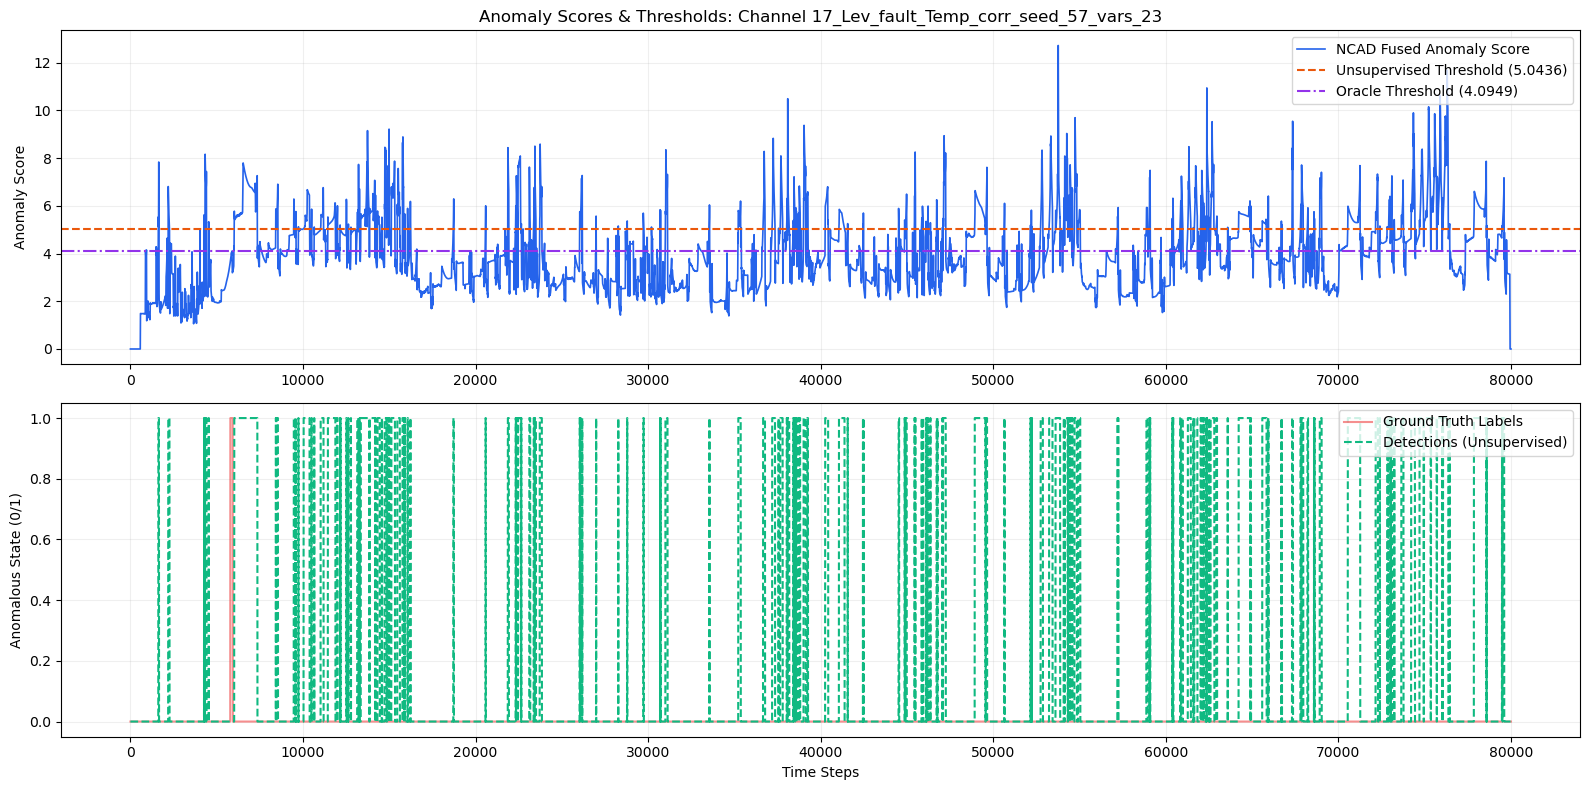

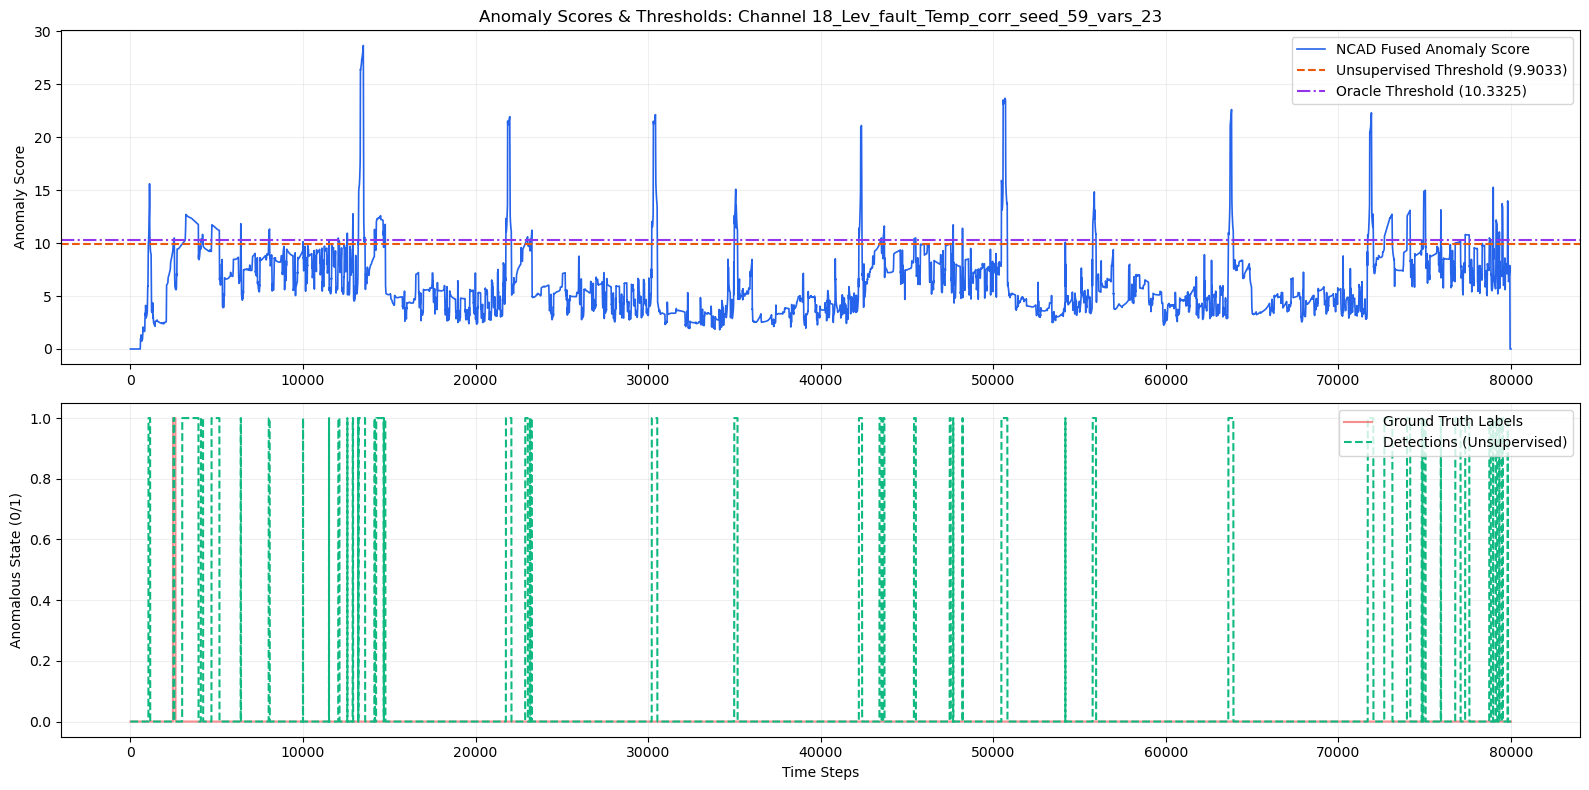

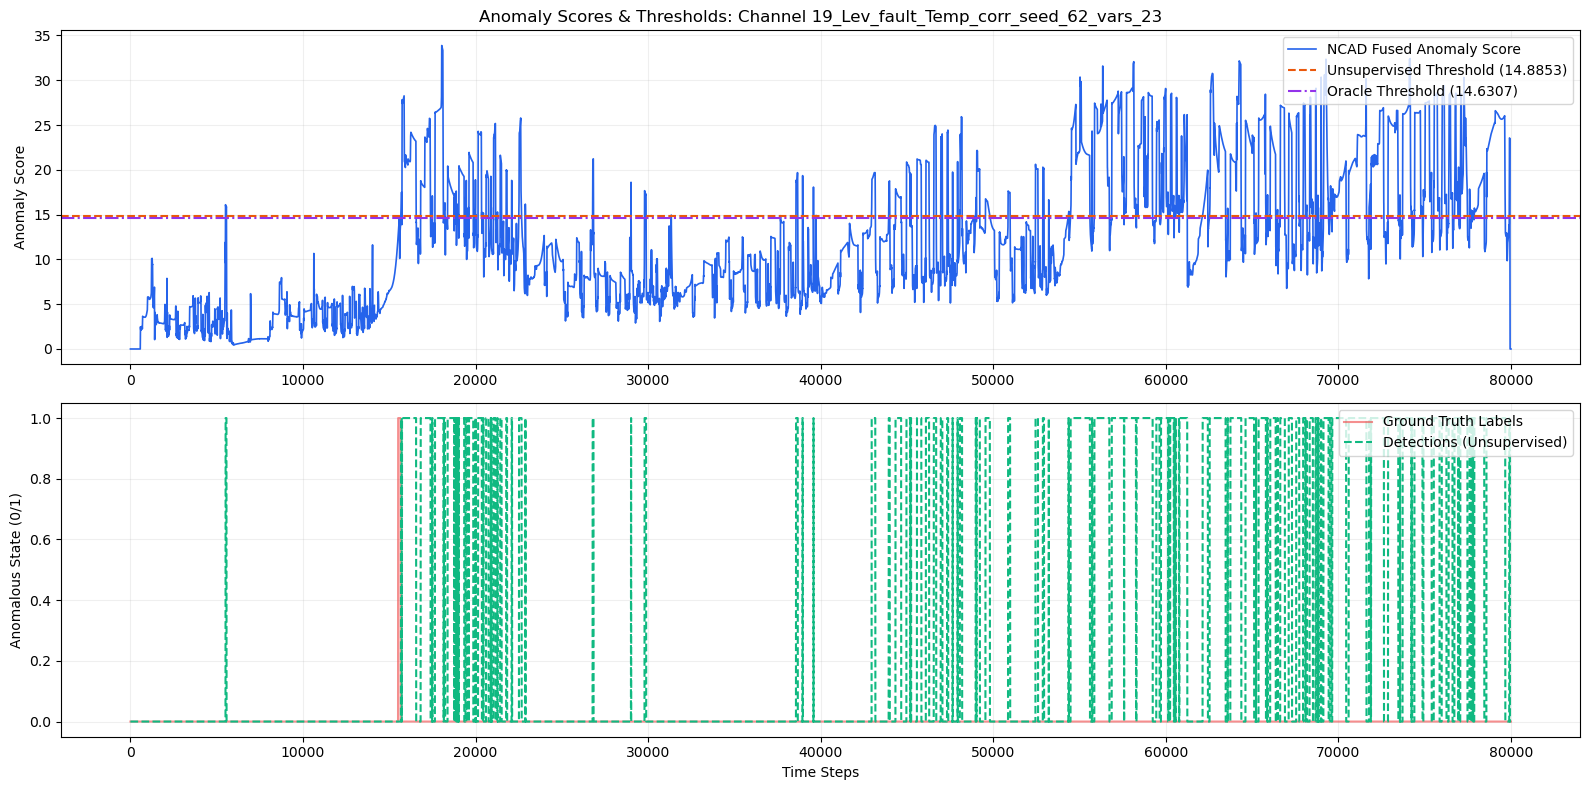

In [4]:
for chan, data in plot_data.items():
    plt.figure(figsize=(16, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(data["scores"], label="NCAD Fused Anomaly Score", color="#2563eb", linewidth=1.2)
    plt.axhline(data["unsub_threshold"], color="#ea580c", linestyle="--", label=f"Unsupervised Threshold ({data['unsub_threshold']:.4f})")
    plt.axhline(data["oracle_threshold"], color="#9333ea", linestyle="-.", label=f"Oracle Threshold ({data['oracle_threshold']:.4f})")
    plt.ylabel("Anomaly Score")
    plt.title(f"Anomaly Scores & Thresholds: Channel {chan}")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.2)
    
    plt.subplot(2, 1, 2)
    preds_unsub = event_level_filter(data["scores"], data["unsub_threshold"], data["valid_mask"], min_run=2, extreme_factor=1.75) * data["valid_mask"].astype(np.float32)
    plt.plot(data["labels"], label="Ground Truth Labels", color="#ef4444", linewidth=1.5, alpha=0.6)
    plt.plot(preds_unsub, label="Detections (Unsupervised)", color="#10b981", linestyle="--", linewidth=1.5)
    plt.ylabel("Anomalous State (0/1)")
    plt.xlabel("Time Steps")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

In [5]:
results_dir = project_root / 'results' / 'notebook_runs'
results_dir.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(results_dir / 'ghl_evaluation.csv', index=False)
print(f"Saved summary table to {results_dir}/ghl_evaluation.csv")

Saved summary table to C:\Users\andre\OneDrive\Desktop\NCAD_CS\results\notebook_runs/ghl_evaluation.csv
